NAME-LALIT PATHADE

ROLL NO - 58

CLASS-CSE(AI) DIV-D

PRN-12411458

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error


In [ ]:
df = pd.read_csv("uber.csv")
df.head()


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [ ]:
df.isnull().sum()


,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,1
dropoff_latitude,1
passenger_count,0


In [ ]:
df.dropna(inplace=True)


In [ ]:
df = df[(df['fare_amount'] > 0)]

df = df[
    (df['pickup_latitude'].between(-90, 90)) &
    (df['dropoff_latitude'].between(-90, 90)) &
    (df['pickup_longitude'].between(-180, 180)) &
    (df['dropoff_longitude'].between(-180, 180))
]


In [ ]:
from math import radians, cos, sin, asin, sqrt

def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    km = 6371 * c
    return km

df['distance_km'] = df.apply(lambda row: haversine(
    row['pickup_latitude'], row['pickup_longitude'],
    row['dropoff_latitude'], row['dropoff_longitude']
), axis=1)


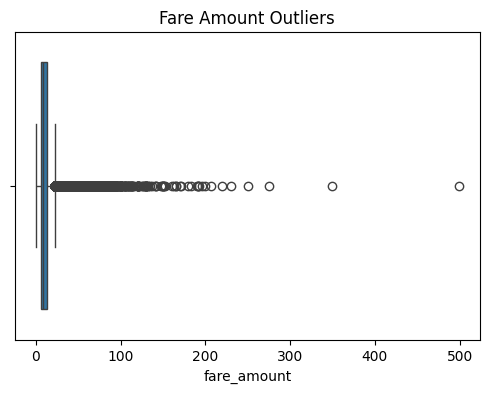

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['fare_amount'])
plt.title("Fare Amount Outliers")
plt.show()


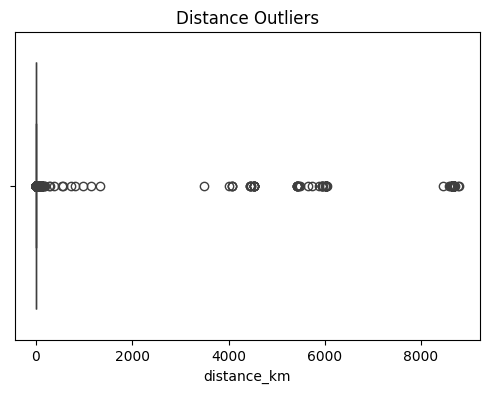

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['distance_km'])
plt.title("Distance Outliers")
plt.show()


In [ ]:
df = df[df['fare_amount'] < 100]
df = df[df['distance_km'] < 50]


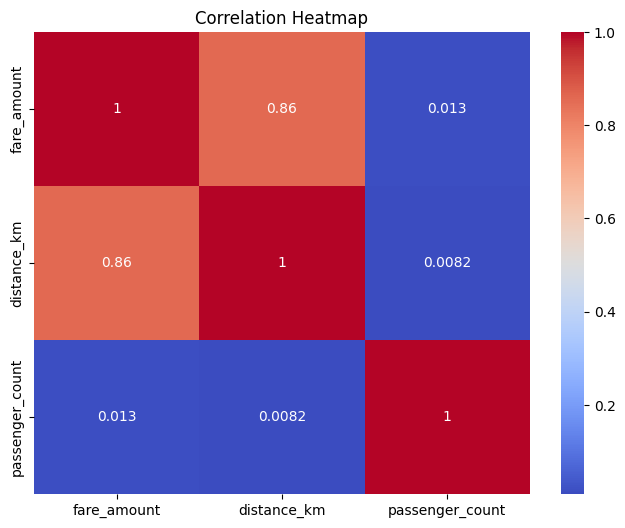

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['fare_amount', 'distance_km', 'passenger_count']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
X = df[['distance_km', 'passenger_count']]
y = df['fare_amount']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


In [ ]:
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression R2:", r2_lr)
print("Linear Regression RMSE:", rmse_lr)


Linear Regression R2: 0.7342473180420661
Linear Regression RMSE: 4.863755405824841


In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)


In [ ]:
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("Ridge R2:", r2_ridge)
print("Ridge RMSE:", rmse_ridge)


Ridge R2: 0.7342473142676136
Ridge RMSE: 4.863755440364499


In [ ]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)


In [ ]:
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("Lasso R2:", r2_lasso)
print("Lasso RMSE:", rmse_lasso)


Lasso R2: 0.7341728190455004
Lasso RMSE: 4.8644370913377415


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "R2 Score": [r2_lr, r2_ridge, r2_lasso],
    "RMSE": [rmse_lr, rmse_ridge, rmse_lasso]
})

results


,Model,R2 Score,RMSE
0,Linear Regression,0.734247,4.863755
1,Ridge,0.734247,4.863755
2,Lasso,0.734173,4.864437


In [ ]:
distance = 10   # km
passengers = 2

predicted_fare = lr.predict([[distance, passengers]])
print("Predicted Fare:", predicted_fare[0])


Predicted Fare: 26.608907148115613


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
